# Section 1 - Project Introduction - Rock, Paper, Scissors - Computer Vision Project


---



**Student Information** - Sagiv L, 1582

**AI usage disclosure:**

* >**Prompt:** "I have chosen a dataset of Rock, Paper, Scissors images. I want to create a classification model that determines which move was made in an image of a hand gesture. Please organize the project requirements into a clear list of steps / sections."<br>
**Purpose:** Ensuring I understand the project requirements properly

* > **Prompt:** "How do I load a dataset composed of images (within a single folder) into a dataframe?"<br>
**Purpose:** Understanding how to properly load multiple images into a single dataframe (as well as the format they were supposed to be loaded in)

* > **Prompt:** How can I display a very long 1D array in subplots<br>
**Purpose:** "Visualizing the feature engineering results in an organized and intelligible manner"

* > **Prompt:** "Give me two HEX codes for colors. Make the first one a skin color, and the second a background that will look identical to the skin color in grayscale"<br>
**Purpose:** Including an example of how grayscaling could harm image coherency

* > **Prompt:** "Would SVM be a viable solution for this problem?"<br>
**Purpose:** Ensuring I could use SVM for this problem. Online sources pointed out that SVM was made obsolete by solutions such as ANNs, so I made sure this model would still be usable within this project regardless.

* > **Prompt:** "What default values should I use for the model's train function?"<br>
**Purpose:** Establishing a baseline to make the Grid Search's result more impactful, without rolling completely random values.

* > **Prompt:** "How do I execute grid search and cross validation in python, on an SVM model?"<br>
**Purpose:** Explaining the Grid Search and 5-Fold Cross Validation process in practice.

* > **Prompt:** "After testing using the optimal hyperparameters from the grid search and cross validation, I ended up getting a worse score than before. Is my code incorrect?"<br>
**Purpose:** Ensuring that the major discrepancy outlined in Section 4 was not the result of bugs / incorrect code.

* > **Prompt:** "Please make sure I have completed every part of the assignment (excluding the last two bonus extensions). If I have made any mistake in my logic / explanation / organization, please highlight it."<br>
**Purpose:** Ensuring that the project was completed in accordance with the specifications.

* >**Notes:** I chose not to add a few minor prompts that were related to syntax / documentation, since they were relatively insignificant and only served to summarize documentation pages. Additionally, I have decided not to use AI to rewrite the explanations (besides a single section where I struggled with wording). This means that there are likely *some* grammar/spelling/formatting issues throughout the project.
<br>

**Sources**:
* https://www.geeksforgeeks.org/ - Generic python documentation
* https://scikit-learn.org/stable/modules/svm.html - Scikit-learn library documentation (more specifically for SVM)<br><br>


**1.0 - Dataset Overview**

---

**Dataset:** The dataset contains 2,892 images of diverse hands in Rock/Paper/Scissors poses, with varied races, ages, and genders.
An important note about the dataset is that it was created through CGI rather than real-world examples.

**Goal:** The goal of this project is to use a machine learning algorithm to identify hand gestures from the game "Rock, Paper, Scissors" in images. Using the model trained on this dataset, we could, for example, classify the move a player made by taking a snapshot of their video feed in a "Rock Paper Scissors" video game.
Coincidentally, this dataset will also allow us to determine the effectiveness of CGI-based datasets for the classification of real-world examples.


**1.1 - Importing project-wide libraries**


---


*I have opted to do this at the top of the project to avoid importing the same
library multiple times by accident*

In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import kagglehub
from PIL import Image
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold

**1.2 - Downloading and Loading the Dataset**

---

In [33]:
# Download latest version of dataset
path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")

Using Colab cache for faster access to the 'rock-paper-scissors-dataset' dataset.


In [34]:
# Loads the dataset from a folder with images into a dataframe
def load_dataset_from_path(base_path):
    filepaths = []
    labels = []

    classes = ['rock', 'paper', 'scissors']

    for class_name in classes:
        class_dir = os.path.join(base_path, class_name)
        # Check if the directory exists just to be safe
        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):
                filepaths.append(os.path.join(class_dir, filename))
                labels.append(class_name)

    # Create dataframe
    df = pd.DataFrame({
        'Filepath': filepaths,
        'Label': labels
    })

    # Shuffle the dataset to avoid 'head' only returning examples
    # from the first folder (class)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

# --------------------------------------------

# The train/test sets are nested inside a parent folder, so we join it to
# the path
base_dataset_dir = os.path.join(path, 'Rock-Paper-Scissors')

# Load datasets by joining the kagglehub path with the respective folder
train_df = load_dataset_from_path(os.path.join(base_dataset_dir, 'train'))
test_df = load_dataset_from_path(os.path.join(base_dataset_dir, 'test'))


**1.3 - Display First 5 Rows**


---



First 5 rows of the Train Set:


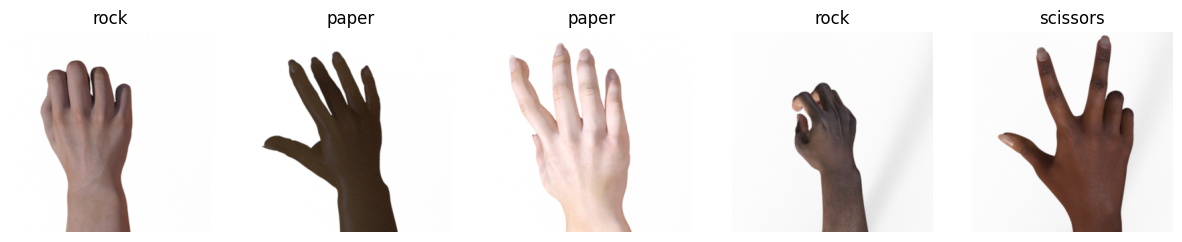


First 5 rows of the Test Set:


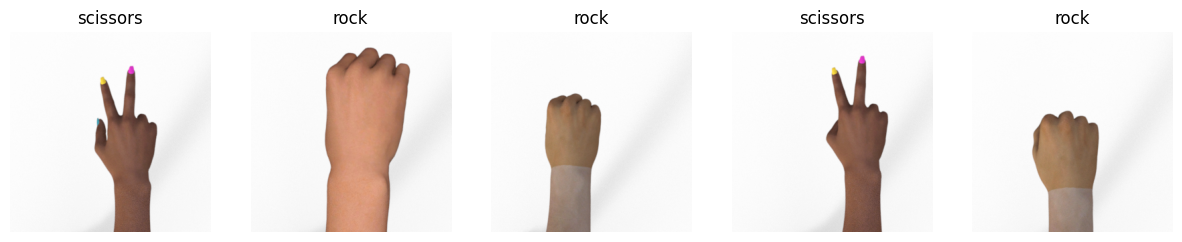

In [35]:
# Display the first 5 rows of each dataset
print("First 5 rows of the Train Set:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img_path = train_df['Filepath'][i]
    label = train_df['Label'][i]
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis('off')
plt.show()

print("\nFirst 5 rows of the Test Set:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img_path = test_df['Filepath'][i]
    label = test_df['Label'][i]
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis('off')
plt.show()

**1.4 - Quality Metric**


---
<br>
Since this is a multi-class problem, we will be using the macro-average-f1 formula:
<br>
<br>

$$\text{Macro F1} = \frac{1}{N} \sum_{i=1}^{N} \text{F1}_i$$

Where $\text{F1}_i = 2 \times \frac{\text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}$

<br>

In the context of this project, the formula can be rewritten as:
<br>
<br>

$$\text{Macro F1} = \frac{\text{F1}_{\text{rock}} + \text{F1}_{\text{paper}} + \text{F1}_{\text{scissors}}}{3}$$

# Section 2 - Feature Engineering

**2.0 - Image Resizing (Downsizing)**

---
<br>

The images in this dataset are officially provided in a uniform 300x300 pixel format. However, as our first feature engineering step, we are implementing a resizing function to downscale these images (initially to 75x75 pixels) for two primary reasons:
*   **Computational Efficiency:** A 300x300 RGB image contains 270,000 individual pixel values (features). This immense feature count makes the model computationally expensive, and increases memory usage and training time amongst other things. Ideally, we would like to resize the images to the smallest size possible to reduce the computational load, while ensuring the model's accuracy isn't harmed.

*   **Uniformity:** While the dataset description claims uniformity, there may be images that do not strictly adhere to this format. To ensure robustness against potential outliers, we manually enforce a uniform size.


In [36]:
# Open image in path and resize it to the target size
def resize_image(image_path, target_size):
    with Image.open(image_path) as img:
        resized_img = img.resize(target_size, Image.Resampling.LANCZOS)
        return resized_img


**2.1 - Grayscaling**

---
<br>

As an additional feature engineering step, we convert the downscaled RGB images into grayscale. This transformation is applied for two primary reasons:

*   **Dimensionality & Computational Reduction:** Moving from RGB format to a grayscale format immediately reduces the data volume per image by a factor of three, lowering memory usage and accelerating model training times.

*   **Removal of Redundant Information:** In a Rock, Paper, Scissors classification task, the specific color of the hand or background is largely irrelevant to the gesture being made. The defining characteristics rely on shape and geometry.

<br>

**Potential Risks & Trade-offs:**
*   **Loss of Color-Based Contrast:** While grayscaling simplifies the data, it strips away information about color. If an image features a background or clothing with a brightness level very similar to the skin tone of the hand, converting to grayscale can flatten the contrast. This can obscure or "blend" the edges and lines of the hand into the background, potentially making it harder for the model to accurately identify the precise boundaries and shape of the gesture. This following example shows how two colors with completely different hues can end up blending into a single color in grayscale:

* 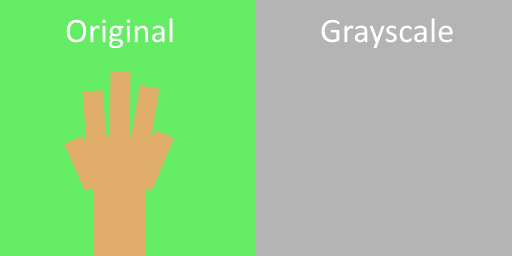

In [37]:
def grayscale_image(img):
    # Convert image to grayscale
    return img.convert('L')

**2.2 - Matrix Flattening**

---
<br>

As a final feature engineering step, we flatten the 2D image matrices into 1D arrays. This transformation is applied for the following reason:

* Algorithmic Compatibility: SVMs cannot natively process 2D data. They expect a standard, 1D feature vector for each data point. This incompatability can be solved using flattening, translating visual matrices into the mathematical array format required for training.


In [38]:
def flatten_image(img):
    # Flattens image into 1D
    return np.array(img).flatten()

**2.2 - Visualization**


---



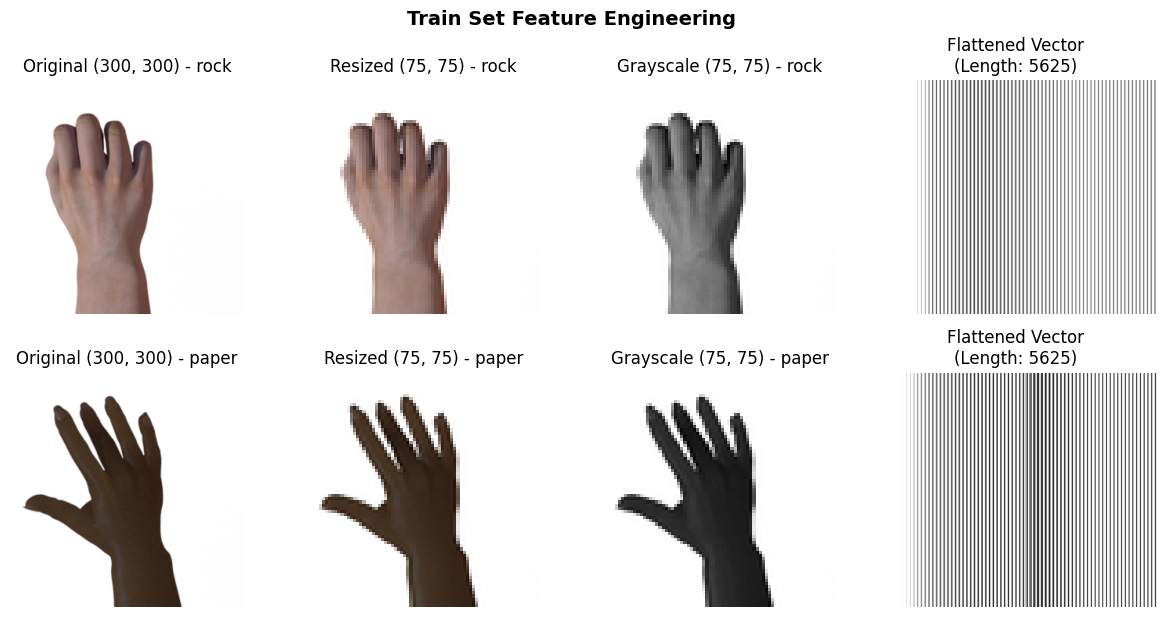

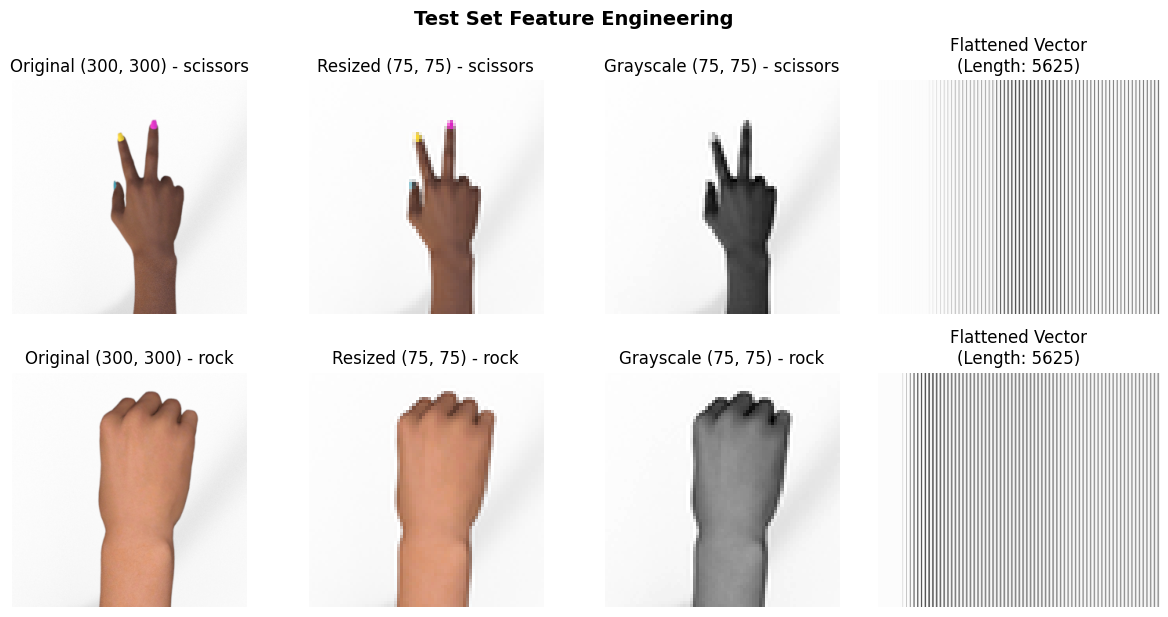

In [39]:
import numpy as np

# Visualize the feature engineering process for a few examples
def visualize_feature_engineering(df, set_name, num_examples, target_size):
    # Increased columns from 3 to 4, and adjusted width from 9 to 12
    fig, axes = plt.subplots(num_examples, 4, figsize=(12, 3 * num_examples))

    for i in range(num_examples):
        img_path = df['Filepath'][i]
        label = df['Label'][i]

        # Open original image
        orig_img = Image.open(img_path)

        # Resize
        resized_img = resize_image(img_path, target_size)

        # Grayscale
        gray_img = grayscale_image(resized_img)

        # Flatten (convert to numpy array and flatten to 1D)
        flattened_img = np.array(gray_img).flatten()

        # Plot original
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"Original {orig_img.size} - {label}")
        axes[i, 0].axis('off')

        # Plot resized
        axes[i, 1].imshow(resized_img)
        axes[i, 1].set_title(f"Resized {target_size} - {label}")
        axes[i, 1].axis('off')

        # Plot grayscale
        axes[i, 2].imshow(gray_img, cmap='gray')
        axes[i, 2].set_title(f"Grayscale {target_size} - {label}")
        axes[i, 2].axis('off')

        # Plot flattened (reshaped to 1xN to render as a visual 'strip')
        # aspect='auto' forces it to fill the subplot height instead of being 1 pixel tall
        axes[i, 3].imshow(flattened_img.reshape(1, -1), cmap='gray', aspect='auto')
        axes[i, 3].set_title(f"Flattened Vector\n(Length: {len(flattened_img)})")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.suptitle(f"{set_name} Set Feature Engineering", y=1.02, fontsize=14, fontweight='bold')
    plt.show()

# Run visualization
visualize_feature_engineering(train_df, set_name="Train", num_examples=2, target_size=(75, 75))
visualize_feature_engineering(test_df, set_name="Test", num_examples=2, target_size=(75, 75))

# Section 3 - Machine Learning Algorithm Implementation

**3.0 - Preprocessing**


---


Here, we apply the feature-engineering steps outlined in section 2 to the **whole** dataset, using the functions we defined.

In [40]:

# Apply feature engineering methods to dataframe
def preprocess_data(df, target_size):
    X = []
    y = df['Label'].values

    for filepath in df['Filepath']:
        # Resize the image
        img_resized = resize_image(filepath, target_size)
        # Convert to grayscale
        img_gray = grayscale_image(img_resized)
        # Flatten into a 1D array
        img_flattened = flatten_image(img_gray)

        X.append(img_flattened)

    return np.array(X), y

**3.1 - Model Implementation**


---

A **Support Vector Machine** (SVM) is a supervised learning algorithm that aims to find the optimal hyperplane (a decision boundary) that separates different classes of data.

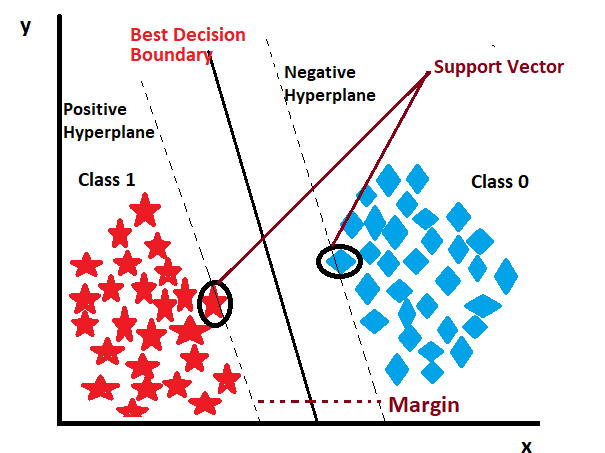

**Kernel:** In cases where data cannot be seperated lineraly (like complex image pixel data), the SVM uses a mathematical technique called a "Kernel". Kernels project the 1D flattened image data into a higher-dimensional space where a linear decision boundary can be drawn effectively.

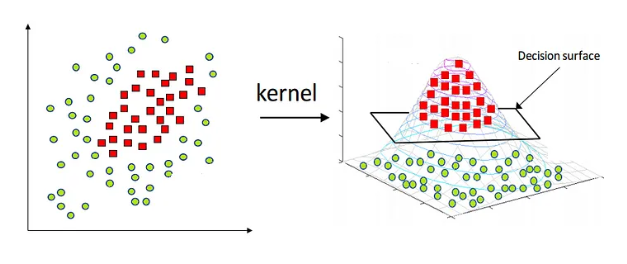

This is an implementation of SVM, using the scikit-learn library.

In [41]:
def train_svm(X_train, y_train, kernel_type='rbf', C_param=1.0):
    # Initialize the SVM classifier
    svm_model = SVC(kernel=kernel_type, C=C_param, random_state=42)

    # Train the model
    svm_model.fit(X_train, y_train)

    return svm_model

**3.2 - Predicting Using the Default Hyperparameters**


---


We will now attempt to create a prediction using the trained model. We will be using hyperparameter and feature engineering parameter values (suggested by Gemini). This will additionally act as a baseline to compare against in Section 4.


In [42]:
# preprocess data
X_train, y_train = preprocess_data(train_df, target_size=(75, 75))
X_test, y_test = preprocess_data(test_df, target_size=(75, 75))

# Train the SVM model
print("Training the SVM model...")
model = train_svm(X_train, y_train, kernel_type='rbf', C_param=1.0)

# Make predictions on the test set
print("Making predictions...")
predictions = model.predict(X_test)

# Evaluate overall F1 score
macro_f1 = f1_score(y_test, predictions, average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}")

# Evaluate individual F1 scores per class
individual_f1 = f1_score(y_test, predictions, average=None)

# Map the scores to their respective class labels
print("\nIndividual Class F1 Scores:")
for class_label, score in zip(model.classes_, individual_f1):
    print(f"{class_label}: {score:.4f}")

Training the SVM model...
Making predictions...
Overall Macro F1 Score: 0.6773

Individual Class F1 Scores:
paper: 0.6194
rock: 0.7097
scissors: 0.7027


Note the model's overall F1 macro score - **0.6773**. This score shows that while the model indeed succeeded in identifying meaningful patterns within the dataset, it only performed moderately well.

<br>

Additionally, we can see that the individual F1 score of paper is lower than that of rock and scissors. This shows that the model struggles with predicting paper slightly more than it does rock and scissors.

<br>

While these results show a major improvement over random-guessing, we may very well improve its performance by tweaking the parameters.

# Section 4 - Training Flow

**4.0 - Preprocessing**


---

We will preprocess the train dataset, as we have in Section 3. We will resize every image in the dataset to (25, 25), which is the ideal parameter (the process for finding this perfect paramter will be outlined in Section 6).

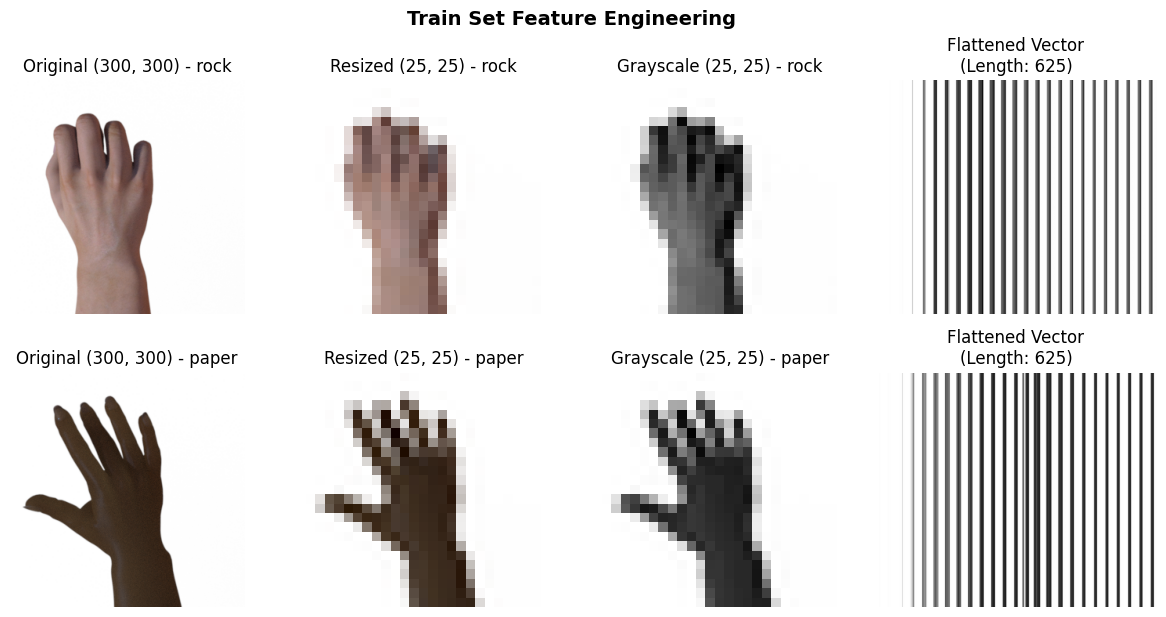

In [43]:
X_train, y_train = preprocess_data(train_df, target_size=(25, 25))

visualize_feature_engineering(train_df, set_name="Train", num_examples=2, target_size=(25, 25))

**4.1 - Training**


---

We will now retrain the model from Section 3 using the optimal hyperparameters discovered in Section 6:

* **Kernel: *linear*** -  As we have mentioned before, the kernel defines the shape of the hyperplane that seperates the classes. 'linear' tells the model to draw a rigid, straight line to seperate the classes. It is computatioanlly fast, and works well when data is easily seperable.

* **Regluarization Parameter C : *0.1*** - The penalty for misclassifying data during training. A high value will heavily penalize misclassifications. This forces the model to strictly adhere to the shape of the data, leading to a high prediction rate on the training set, but introducing a risk of overfitting.
The value optimal hyperparameter **0.1** is very low, which causes the model to prioritize creating a smoother, consistent boundry, even if some of the data is misclassified uring training. This allows the model to generalize better to new data. Low values run the risk of underfitting the model, because the model may fail to capture important underlying patterns.

In [44]:
# Train
print("Training the SVM model...")
model = train_svm(X_train, y_train, kernel_type='linear', C_param=0.1)

Training the SVM model...


# Section 5 - Prediction and Evaluation

**5.0 - Preprocessing**


---



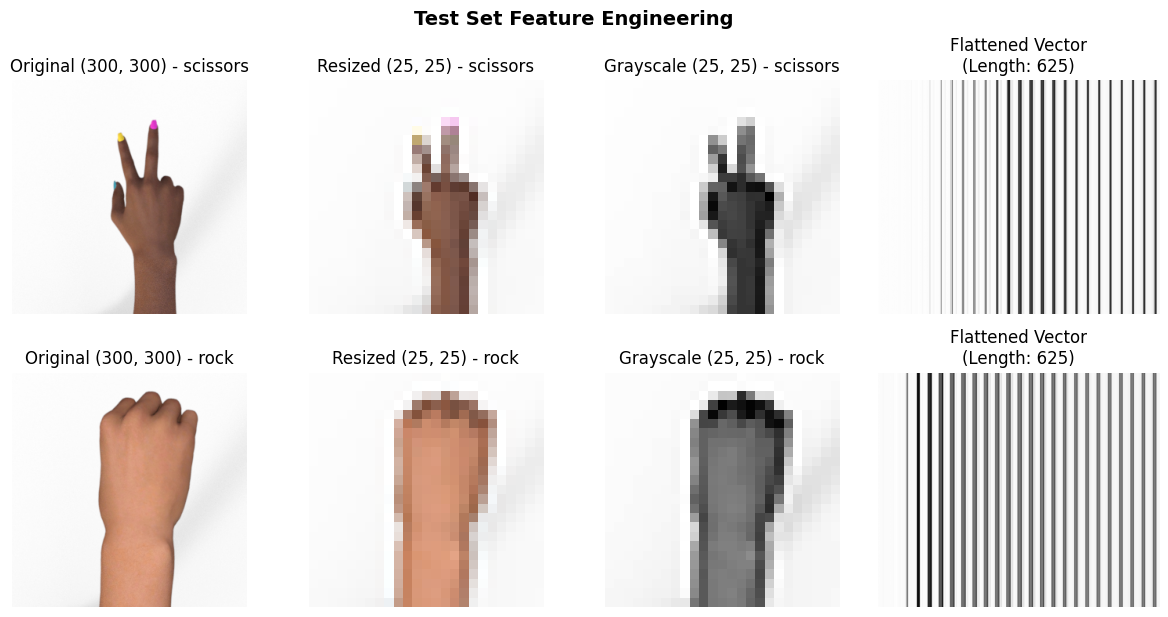

In [45]:
# Preprocess (resize to 25x25)
visualize_feature_engineering(test_df, set_name="Test", num_examples=2, target_size=(25, 25))
X_test, y_test = preprocess_data(test_df, target_size=(25, 25))

**5.1 - Prediction**


---

We will now predict the test set's labels using the model trained in the previous section.

In [46]:
# Make predictions on the test set
print("Making predictions...")
predictions = model.predict(X_test)


# Show classifications
print("\nFirst 5 Classifications:")
for i in range(5):
    print(f"True Label: {y_test[i]} | Predicted: {predictions[i]}")


# Quality estimation
# Evaluate overall F1 score
macro_f1 = f1_score(y_test, predictions, average='macro')
print(f"\nOverall Macro F1 Score: {macro_f1:.4f}")

# Evaluate individual F1 scores per class
individual_f1 = f1_score(y_test, predictions, average=None)

# Map the scores to their respective class labels
print("\nIndividual Class F1 Scores:")
for class_label, score in zip(model.classes_, individual_f1):
    print(f"{class_label}: {score:.4f}")

Making predictions...

First 5 Classifications:
True Label: scissors | Predicted: scissors
True Label: rock | Predicted: paper
True Label: rock | Predicted: rock
True Label: scissors | Predicted: scissors
True Label: rock | Predicted: scissors

Overall Macro F1 Score: 0.6657

Individual Class F1 Scores:
paper: 0.6782
rock: 0.5789
scissors: 0.7401


Our overall macro score using the optimal hyperparameters is 0.6657, which is notably lower than the baseline parameters showcased in Section 3.

<br>


But how could this be the case? In Section 6, our Grid Search with 5-Fold Cross Validation found a permutation with a perfect F1 score of 1.0.

<br>



**5.2 - Identifying the Problem**



---



After inspecting the dataset directly, I found the culprit: severe data leakage during the cross-validation phase. Because this dataset was generated using CGI rather than real-world examples, many images are sequential frames that are nearly identical, differing only slightly in rotation and distance:


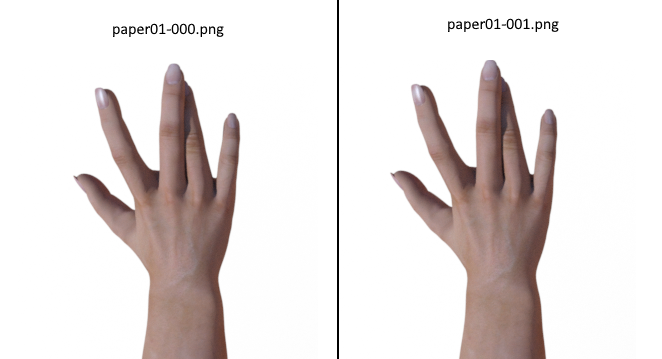
* Note - Using a dedicated tool, I made sure that these images are indeed different
<br>

When we loaded and shuffled the dataset, these near-duplicate images were scattered across all 5 folds. Furthermore, any minor differences between these frames were likely erased entirely when we downscaled the images during feature engineering, leaving completely identical images in both the training and validation splits.


<br>


To prove this, we can look at the baseline permutation from Section 3:


> * target_size: 75x75
> * kernel: rbf
> * Regularization Parameter C: 1.0

<br>

The 5-Fold Cross Validation process divides the trainset into 5 equal parts -training on 4 parts and validating on the remaining 1. Its purpose is to estimate how the model will handle genuinely unseen data, meaning the cross-validation score and final test score should ideally be very similar.  

<br>

By comparing the exact same permutation across both evaluation methods, the massive drop in the macro-average-f1 score-from a perfect 1.0 down to 0.6773 provides clear proof. It isolates the dataset as the only changing variable, proving without a doubt that our validation folds were artificially easy.  

<br>

Because the leaked CGI duplicates were scattered across all 5 folds, the model bypassed learning complex hand geometry in favor of trivial pixel-matching. This tricked the Grid Search into rewarding an underfitted model. It selected an extremely downscaled target_size of 25x25 and a rigid linear boundary because the leaked data made the classification task trivially easy, ultimately causing the model to fail when exposed to the truly distinct images in the test set.


# Section 6 - Bonus Section (Grid Search + 5-Fold Cross Validation

6.0 - Grid Search With 5-Fold Cross Validation


---

**Grid Search** - Grid Search is a tuning technique where we systematically test all possible permutations of our chosen parameters. In the code, I defined three lists of hyperparameters and feature engineering parameters:
* image_sizes
* svm_kernels
* c_params.

<br>

By utilizing nested for loops, the code creates a Cartesian product of these options. This means the algorithm iterates through every single possible combination- for example, pairing a 25x25 target size with a linear kernel and a C parameter of 0.1- before moving on to test the next configuration.

<br>
<br>


**5-Fold Cross Validation** - To evaluate the true effectiveness of each permutation without touching our final test set, we wrap the training phase in a 5-Fold Cross Validation. This process divides the trainset into 5 equal parts.
  
For every individual permutation generated by the Grid Search, the cross-validation loop runs 5 times. In each iteration, the model uses 4 of those parts for training, and validates its predictions on the remaining 1 validation part. During each fold, the model calculates the macro-average-f1 score.

In [ ]:
# Permutations
image_sizes = [(25, 25), (50, 50), (75, 75)]       # Image sizes
svm_kernels = ['linear', 'rbf']          # Kernel type
c_params = [0.1, 1.0, 10.0]              # Regularization parameter (Hyperparameter)

# Initialize 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

print("Starting Grid Search with 5-Fold Cross Validation...")

# Execute the Grid Search Loop9
for size in image_sizes: # Iterate over all image sizes
    print(f"Extracting features for image size {size}...")
    X_train_full, y_train_full = preprocess_data(train_df, size)

    for kernel in svm_kernels: # Iterate over all kernel types
        for c_val in c_params:
            fold_scores = []

            # Run the 5-fold cross-validation
            for train_index, val_index in kf.split(X_train_full):
                X_fold_train, X_fold_val = X_train_full[train_index], X_train_full[val_index]
                y_fold_train, y_fold_val = y_train_full[train_index], y_train_full[val_index]

                # Train
                model = train_svm(X_fold_train, y_fold_train, kernel_type=kernel, C_param=c_val)

                # Predict and calculate Macro F1
                preds = model.predict(X_fold_val)
                score = f1_score(y_fold_val, preds, average='macro')
                fold_scores.append(score)

            # Calculate the average Macro F1 across all 5 folds
            avg_score = np.mean(fold_scores)

            # Store the permutation and its result
            results.append({
                'Image Size': f"{size[0]}x{size[1]}",
                'Kernel': kernel,
                'C Parameter': c_val,
                'Avg Macro F1 Score': avg_score
            })

# Results
# Convert results to a dataframe
results_df = pd.DataFrame(results)

# Sort the dataframe to show the best results at the top
results_df = results_df.sort_values(by='Avg Macro F1 Score', ascending=False).reset_index(drop=True)

Starting Grid Search with 5-Fold Cross Validation...
Extracting features for image size (25, 25)...
Extracting features for image size (50, 50)...
Extracting features for image size (75, 75)...


**6.1 - Full Results**


---

As we mentioned in Section 5, the results show an abnormally high F1 score for every permutation, which shows that the parameters we give to the model have a minimal effect on its accuracy during the 5-Fold Cross Validation process.

In [ ]:
display(results_df)

**6.2 - Optimal Result**


---

The optimal result from the Grid Search is the one with the highest F1 score. The 6 top permutations all have an identical, perfect F1 score of 1.0.

We will trivially choose the first permutation from the top as the optimal solution:

> * target_size: 25x25
> * kernel: linear
> * Regularization Parameter C: 0.1

<br>


In [ ]:
# Single best permutation
best_permutation = results_df.iloc[0]
print("\n--- BEST PERMUTATION ---")
print(f"The most successful permutation achieved a Macro F1 Score of {best_permutation['Avg Macro F1 Score']:.4f}")
print(f"Settings: Image Size: {best_permutation['Image Size']}, Kernel: {best_permutation['Kernel']}, C: {best_permutation['C Parameter']}")